In [20]:
# ================================================================
# Label-efficiency with Copernicus-FM (frozen) for Water Mapping
# Fractions explored: {10, 20, 30, 50, 100} %
# Dataset: https://huggingface.co/datasets/giswqs/geospatial/resolve/main/waterbody-dataset.zip
# ================================================================

import os, math, time, zipfile, shutil, urllib.request, random, glob
from pathlib import Path
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# ---- Copernicus-FM from torchgeo
from torchgeo.models import copernicusfm_base, CopernicusFM_Base_Weights

# ----------------------------- Repro -----------------------------
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# --------------------- Dataset (waterbody) -----------------------
def download_and_unzip(url, out_dir="waterbody_dataset"):
    out_dir = Path(out_dir)
    if (out_dir/"images").exists() and (out_dir/"masks").exists():
        print(f"Found dataset at: {out_dir}")
        return out_dir
    out_dir.mkdir(parents=True, exist_ok=True)
    zip_path = out_dir/"waterbody.zip"
    print("Downloading dataset...")
    urllib.request.urlretrieve(url, zip_path)
    print("Unzipping...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(out_dir)
    # bubble-up possible nested folders named images/ and masks/
    def bubble_up(folder_name):
        candidates = list(out_dir.rglob(folder_name))
        for c in candidates:
            if c.is_dir() and c.parent != out_dir:
                target = out_dir/folder_name
                target.mkdir(exist_ok=True)
                for p in c.glob("*"):
                    shutil.move(str(p), str(target/p.name))
        return out_dir/folder_name
    images = bubble_up("images"); masks = bubble_up("masks")
    assert images.exists() and masks.exists(), "images/ and masks/ not found after unzip."
    zip_path.unlink(missing_ok=True)
    print(f"Dataset ready at: {out_dir}")
    return out_dir

URL = "https://huggingface.co/datasets/giswqs/geospatial/resolve/main/waterbody-dataset.zip"
DATA_ROOT = download_and_unzip(URL, out_dir="waterbody_dataset")
IMG_DIR, MSK_DIR = Path(DATA_ROOT/"images"), Path(DATA_ROOT/"masks")

def list_pairs(img_dir, msk_dir, img_exts=("jpg","jpeg","png"), msk_exts=("jpg","jpeg","png")):
    imgs = []
    for e in img_exts: imgs += list(img_dir.glob(f"*.{e}"))
    imgs = sorted(imgs)
    mask_map = {}
    for e in msk_exts:
        for p in msk_dir.glob(f"*.{e}"): mask_map[p.stem] = p
    pairs=[]
    for ip in imgs:
        mp = mask_map.get(ip.stem, None)
        if mp is not None: pairs.append((ip, mp))
    return pairs

pairs = list_pairs(IMG_DIR, MSK_DIR)
print(f"Pairs found: {len(pairs)}")
assert len(pairs)>0, "No image/mask pairs."

# ------------------------- Preprocess ----------------------------
IMG_SIZE = 256   # must match encoder contract below

def letterbox_to_square(im_pil, mask_pil=None, size=IMG_SIZE):
    w,h = im_pil.size
    scale = size / min(w,h)
    nw, nh = max(1,int(round(w*scale))), max(1,int(round(h*scale)))
    im = im_pil.resize((nw, nh), Image.BILINEAR)
    mm = mask_pil.resize((nw, nh), Image.NEAREST) if mask_pil is not None else None
    # center crop/pad
    left = (nw-size)//2; top=(nh-size)//2; box=(left, top, left+size, top+size)
    if nw>=size and nh>=size:
        im = im.crop(box); mm = mm.crop(box) if mm is not None else None
    else:
        bg = Image.new("RGB",(size,size),(0,0,0)); bg.paste(im,((size-nw)//2,(size-nh)//2)); im=bg
        if mm is not None:
            bgm=Image.new("L",(size,size),0); bgm.paste(mm,((size-nw)//2,(size-nh)//2)); mm=bgm
    return im, mm

def compute_mean_std(paths, sample_k=800):
    sel = paths if len(paths)<=sample_k else random.sample(paths, sample_k)
    acc=np.zeros(3,np.float64); acc2=np.zeros(3,np.float64); n=0
    for p in sel:
        im = Image.open(p).convert("RGB")
        im,_ = letterbox_to_square(im,None,IMG_SIZE)
        arr = np.asarray(im,dtype=np.float32)/255.0
        m = arr.reshape(-1,3).mean(0); v=(arr.reshape(-1,3)**2).mean(0)
        acc += m; acc2 += v; n += 1
    mean=(acc/n).astype(np.float32); var=(acc2/n)-(mean**2); std=np.sqrt(np.clip(var,1e-8,None)).astype(np.float32)
    return mean, std

# fixed split (val/test independent), mean/std from full train for stability
train_ratio, val_ratio = 0.8, 0.1
perm = np.random.permutation(len(pairs))
pairs = [pairs[i] for i in perm]
n=len(pairs); n_tr=int(round(n*train_ratio)); n_va=int(round(n*val_ratio))
train_pairs_full, val_pairs, test_pairs = pairs[:n_tr], pairs[n_tr:n_tr+n_va], pairs[n_tr+n_va:]
mean_rgb, std_rgb = compute_mean_std([p for p,_ in train_pairs_full], 800)
print("mean:", np.round(mean_rgb,4), "std:", np.round(std_rgb,4))

class WaterDS(Dataset):
    def __init__(self, pairs, mean, std, augment=False):
        self.pairs=pairs; self.m=torch.tensor(mean).view(3,1,1); self.s=torch.tensor(std).view(3,1,1)
        self.augment=augment
    def __len__(self): return len(self.pairs)
    def _norm(self,x): return (x-self.m)/(self.s+1e-6)
    def _aug(self,x,y):
        if random.random()<0.5: x=torch.flip(x,[2]); y=torch.flip(y,[1])
        if random.random()<0.5: x=torch.flip(x,[1]); y=torch.flip(y,[0])
        if random.random()<0.5:
            k=random.randint(0,3)
            if k: x=torch.rot90(x,k,[1,2]); y=torch.rot90(y,k,[0,1])
        return x,y
    def __getitem__(self,idx):
        ip,mp=self.pairs[idx]
        im = Image.open(ip).convert("RGB")
        mm = Image.open(mp).convert("L")
        im,mm = letterbox_to_square(im,mm,IMG_SIZE)
        img = torch.from_numpy(np.asarray(im,dtype=np.float32).transpose(2,0,1)/255.0)
        msk = torch.from_numpy((np.asarray(mm,dtype=np.uint8)>=128).astype(np.int64))
        img=self._norm(img)
        if self.augment: img,msk=self._aug(img,msk)
        return {"image":img, "mask":msk}

# ------------------- Encoder contract + wrapper ------------------
ENCODER_CONTRACT = {
    "model": "copernicusfm_base",
    "weights": "CopernicusFM_ViT",
    "input_mode": "spectral",         # we'll use patch_embed_spectral directly
    # torchgeo expects wavelengths/bandwidths in *nanometers*
    "wavelengths_nm": [480, 560, 650],
    "bandwidths_nm":  [50,  50,  50],
    "kernel_size": 16,                # patch size for tokenization
    "img_size": IMG_SIZE,
}

class CopFMSegWrapper(nn.Module):
    """
    Robust feature extractor: returns a 4D map [B,C,S,S].
    Uses patch_embed_spectral to avoid metadata requirements.
    """
    def __init__(self, enc, kernel_size, wvs_nm, bws_nm):
        super().__init__()
        self.enc = enc.eval()
        for p in self.enc.parameters(): p.requires_grad = False
        self.ks  = kernel_size
        self.register_buffer("wvs_nm", torch.tensor(wvs_nm, dtype=torch.float32), persistent=False)
        self.register_buffer("bws_nm", torch.tensor(bws_nm, dtype=torch.float32), persistent=False)
        if not hasattr(self.enc, "patch_embed_spectral"):
            raise AttributeError("CopernicusFM build has no 'patch_embed_spectral'. Use a torchgeo version where it exists.")
    @staticmethod
    def _tokens_to_map(tokens: torch.Tensor) -> torch.Tensor:
        assert tokens.ndim == 3, f"Expected [B,N,D], got {tokens.shape}"
        B, N, D = tokens.shape
        S = int(round(N ** 0.5))
        assert S * S == N, f"Token length {N} is not a perfect square"
        return tokens.reshape(B, S, S, D).permute(0, 3, 1, 2).contiguous()
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        with torch.no_grad():
            toks = self.enc.patch_embed_spectral(
                x,
                wavelengths=self.wvs_nm.to(x.device),
                bandwidths=self.bws_nm.to(x.device),
                kernel_size=self.ks,
            )  # [B,N,D]
        return self._tokens_to_map(toks)  # [B,D,S,S]

# Build frozen CopFM encoder & probe shape
copfm = copernicusfm_base(weights=CopernicusFM_Base_Weights.CopernicusFM_ViT)
encoder = CopFMSegWrapper(
    copfm,
    kernel_size=ENCODER_CONTRACT["kernel_size"],
    wvs_nm=ENCODER_CONTRACT["wavelengths_nm"],
    bws_nm=ENCODER_CONTRACT["bandwidths_nm"],
).to(device).eval()
for p in encoder.parameters(): p.requires_grad=False

with torch.no_grad():
    probe = torch.zeros(2,3,IMG_SIZE,IMG_SIZE,device=device)
    feat  = encoder(probe)   # [2,C,S,S]
C_ENC, S_ENC = feat.shape[1], feat.shape[2]
print(f"Encoder feature: C={C_ENC}, S={S_ENC} (IMG={IMG_SIZE}, patch_k={ENCODER_CONTRACT['kernel_size']})")

# ------------------------- Small decoder -------------------------
def GN(ch):
    g = 32 if ch>=32 else max(1, ch//2)
    return nn.GroupNorm(g, ch)

NUM_CLASSES = 2
class SmallDecoder(nn.Module):
    def __init__(self, in_ch, num_classes=NUM_CLASSES, out_size=(IMG_SIZE,IMG_SIZE)):
        super().__init__()
        m1, m2 = in_ch//2, in_ch//4
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, m1, 3, padding=1), GN(m1), nn.ReLU(True), nn.Dropout2d(0.1),
            nn.Conv2d(m1,  m2, 3, padding=1), GN(m2), nn.ReLU(True), nn.Dropout2d(0.1),
            nn.Conv2d(m2,  num_classes, 1),
        )
        self.out_size = out_size
    def forward(self, x):
        x = self.net(x)
        return F.interpolate(x, size=self.out_size, mode="bilinear", align_corners=False)

# ---------------------- Train / Eval utils -----------------------
EPOCHS=100; LR=1e-4; WD=1e-4; USE_DICE=True
criterion = nn.CrossEntropyLoss()

@torch.no_grad()
def forward_feats(x):  # encoder is frozen
    return encoder(x)

def dice_loss_mc(logits, y, eps=1e-6, C=NUM_CLASSES):
    probs = torch.softmax(logits, dim=1)
    y1 = torch.zeros_like(probs).scatter_(1, y.unsqueeze(1), 1.0)
    inter = (probs*y1).sum(dim=(0,2,3))
    den   = (probs+y1).sum(dim=(0,2,3))
    dice  = (2*inter+eps)/(den+eps)
    return 1.0 - dice.mean()

def pixel_acc(logits, y):
    pred = logits.argmax(1)
    return (pred==y).sum().item(), y.numel()

@torch.no_grad()
def eval_metrics(decoder, loader):
    decoder.eval()
    corr=0; totpix=0
    inter=np.zeros(NUM_CLASSES,np.int64); union=np.zeros(NUM_CLASSES,np.int64)
    for b in loader:
        x=b["image"].to(device); y=b["mask"].to(device)
        f=forward_feats(x)
        pred=decoder(f).argmax(1)
        corr+=(pred==y).sum().item(); totpix+=y.numel()
        p=pred.cpu().numpy().ravel(); g=y.cpu().numpy().ravel()
        for c in range(NUM_CLASSES):
            pi=(p==c); gi=(g==c)
            tp = np.logical_and(pi,gi).sum()
            un = np.logical_or (pi,gi).sum()
            inter[c]+=tp; union[c]+=un
    oa = corr/max(1,totpix)
    iou_c = inter/np.maximum(1,union)
    dice_c = (2*inter)/np.maximum(1,2*inter + (union - inter))  # 2TP/(2TP+FP+FN)
    return float(oa), float(iou_c.mean()), float(dice_c.mean())

def model_size_mb(model):
    # rough: float32 params only
    n_params = sum(p.numel() for p in model.parameters())
    return n_params*4/1e6

# ------------------------ Fractions loop -------------------------
FRACS = [10, 20, 30, 50, 100]  # percent
BATCH=16; WORKERS=0
RESULTS = []
SAVE_DIR = Path("copfm_label_eff_models"); SAVE_DIR.mkdir(exist_ok=True)

# fixed val/test loaders
val_dl   = DataLoader(WaterDS(val_pairs,  mean_rgb,std_rgb,augment=False), batch_size=BATCH, shuffle=False, num_workers=WORKERS)
test_dl  = DataLoader(WaterDS(test_pairs, mean_rgb,std_rgb,augment=False), batch_size=BATCH, shuffle=False, num_workers=WORKERS)

for frac in FRACS:
    # subset of train pairs
    k = max(1, int(len(train_pairs_full)*frac/100.0))
    train_pairs = train_pairs_full[:k]  # deterministic by prior permutation
    train_dl = DataLoader(WaterDS(train_pairs, mean_rgb, std_rgb, augment=True),
                          batch_size=BATCH, shuffle=True, num_workers=WORKERS, drop_last=False)

    # fresh decoder
    decoder = SmallDecoder(in_ch=C_ENC).to(device)
    opt = torch.optim.AdamW(decoder.parameters(), lr=LR, weight_decay=WD)

    # log counts/params
    params_total = sum(p.numel() for p in decoder.parameters())
    params_trainable = sum(p.numel() for p in decoder.parameters() if p.requires_grad)
    ms_mb = model_size_mb(decoder)

    # quick inference timing probe (decoder only, encoder frozen)
    decoder.eval()
    xb = next(iter(train_dl))["image"].to(device)
    with torch.no_grad():
        fb = forward_feats(xb)
        t0=time.time()
        for _ in range(10):
            _ = decoder(fb)
        torch.cuda.synchronize() if torch.cuda.is_available() else None
        infer_ms = (time.time()-t0)/10*1000.0/xb.shape[0]  # per image

    # training
    print(f"\n=== Fraction {frac}% | train images: {k} ===")
    t_train0 = time.time()
    for ep in range(1, EPOCHS+1):
        decoder.train()
        tot=0.0; corr=0; totpix=0
        for b in train_dl:
            x=b["image"].to(device); y=b["mask"].to(device)
            with torch.no_grad(): f=forward_feats(x)
            logits = decoder(f)
            loss = criterion(logits,y) + (dice_loss_mc(logits,y) if USE_DICE else 0.0)
            opt.zero_grad(); loss.backward(); opt.step()
            c,t = pixel_acc(logits,y); corr+=c; totpix+=t
            tot += float(loss.item())
        tr_loss = tot/max(1,len(train_dl)); tr_oa = corr/max(1,totpix)
        va_oa, va_iou, va_dice = eval_metrics(decoder, val_dl)
        print(f"Epoch {ep:02d} | loss {tr_loss:.4f} | val_OA {va_oa:.4f} | val_IoU {va_iou:.4f} | val_Dice {va_dice:.4f}")
    train_time_s = time.time()-t_train0

    # final metrics (val + test)
    val_OA, val_IoU, val_Dice = eval_metrics(decoder, val_dl)
    test_OA, test_IoU, test_Dice = eval_metrics(decoder, test_dl)

    # save decoder only (safe fields)
    ckpt_path = SAVE_DIR/f"copfm_frac_{frac:02d}.pth"
    torch.save({
        "decoder_state": decoder.state_dict(),
        "in_ch": C_ENC,
        "num_classes": NUM_CLASSES,
        "img_size": IMG_SIZE,
        "encoder_contract": ENCODER_CONTRACT,  # for traceability
    }, ckpt_path)

    RESULTS.append({
        "fraction_pct": frac,
        "n_train_imgs": k,
        "params_total": params_total,
        "params_trainable": params_trainable,
        "model_size_MB": ms_mb,
        "train_time_s": train_time_s,
        "infer_ms_per_img": infer_ms,
        "val_OA": val_OA, "val_IoU": val_IoU, "val_Dice": val_Dice,
        "test_OA": test_OA, "test_IoU": test_IoU, "test_Dice": test_Dice,
        "ckpt": str(ckpt_path),
    })



device: cuda
Found dataset at: waterbody_dataset
Pairs found: 2841
mean: [0.3407 0.3721 0.4114] std: [0.1849 0.1489 0.1516]
Encoder feature: C=768, S=16 (IMG=256, patch_k=16)

=== Fraction 10% | train images: 227 ===
Epoch 01 | loss 1.0422 | val_OA 0.7537 | val_IoU 0.5769 | val_Dice 0.7257
Epoch 02 | loss 0.8773 | val_OA 0.7590 | val_IoU 0.5884 | val_Dice 0.7361
Epoch 03 | loss 0.8620 | val_OA 0.7549 | val_IoU 0.5561 | val_Dice 0.7028
Epoch 04 | loss 0.8246 | val_OA 0.7518 | val_IoU 0.5696 | val_Dice 0.7185
Epoch 05 | loss 0.7948 | val_OA 0.7560 | val_IoU 0.5809 | val_Dice 0.7292
Epoch 06 | loss 0.7900 | val_OA 0.7659 | val_IoU 0.5961 | val_Dice 0.7421
Epoch 07 | loss 0.7786 | val_OA 0.7720 | val_IoU 0.6147 | val_Dice 0.7589
Epoch 08 | loss 0.7539 | val_OA 0.7800 | val_IoU 0.6223 | val_Dice 0.7641
Epoch 09 | loss 0.7300 | val_OA 0.7921 | val_IoU 0.6298 | val_Dice 0.7684
Epoch 10 | loss 0.7251 | val_OA 0.7910 | val_IoU 0.6361 | val_Dice 0.7745
Epoch 11 | loss 0.7446 | val_OA 0.7639 | va

In [21]:
# ----------------------- Results dataframe -----------------------
import pandas as pd
df = pd.DataFrame(RESULTS).sort_values("fraction_pct").reset_index(drop=True)
from pprint import pprint
print("\n== Summary ==")
#pprint(df.to_dict(orient="list"))
df



== Summary ==


,fraction_pct,n_train_imgs,params_total,params_trainable,model_size_MB,train_time_s,infer_ms_per_img,val_OA,val_IoU,val_Dice,test_OA,test_IoU,test_Dice,ckpt
0,10,227,3319874,3319874,13.279496,795.460291,0.111264,0.833849,0.694638,0.817241,0.824356,0.683704,0.809820,copfm_label_eff_models\copfm_frac_10.pth
1,20,454,3319874,3319874,13.279496,1107.425654,0.903435,0.854971,0.730846,0.842849,0.839285,0.708203,0.827435,copfm_label_eff_models\copfm_frac_20.pth
2,30,681,3319874,3319874,13.279496,1426.552567,0.980029,0.865877,0.750467,0.856236,0.852306,0.730578,0.843063,copfm_label_eff_models\copfm_frac_30.pth
3,50,1136,3319874,3319874,13.279496,2047.184678,0.829303,0.868142,0.751562,0.856732,0.853025,0.729324,0.841970,copfm_label_eff_models\copfm_frac_50.pth
4,100,2273,3319874,3319874,13.279496,3601.210922,0.786708,0.874147,0.763747,0.864957,0.864777,0.749193,0.855435,copfm_label_eff_models\copfm_frac_100.pth


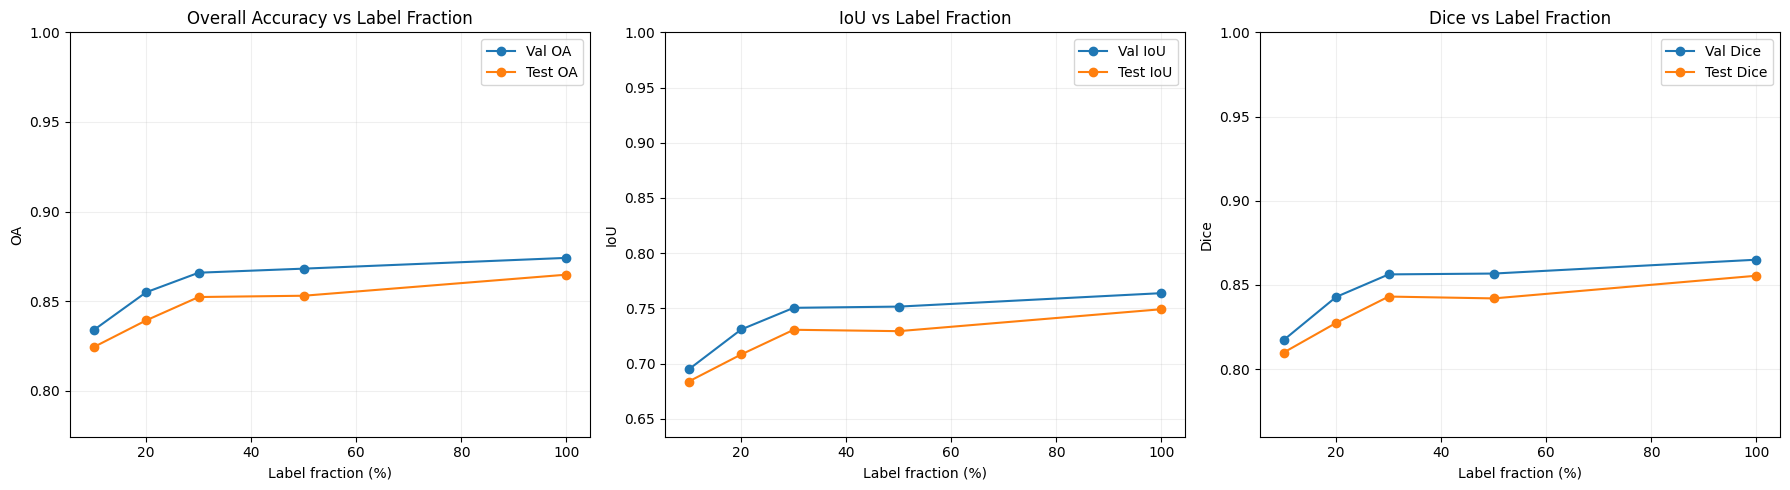

In [22]:
# ---------------------------- Plots ------------------------------
plt.figure(figsize=(18,5))
ax1=plt.subplot(1,3,1)
ax1.plot(df["fraction_pct"], df["val_OA"], 'o-', label="Val OA")
ax1.plot(df["fraction_pct"], df["test_OA"], 'o-', label="Test OA")
ax1.set_title("Overall Accuracy vs Label Fraction"); ax1.set_xlabel("Label fraction (%)"); ax1.set_ylabel("OA")
ax1.set_ylim(max(0.5, df[["val_OA","test_OA"]].min().min()-0.05), 1.0)
ax1.grid(True,alpha=0.2); ax1.legend()

ax2=plt.subplot(1,3,2)
ax2.plot(df["fraction_pct"], df["val_IoU"], 'o-', label="Val IoU")
ax2.plot(df["fraction_pct"], df["test_IoU"], 'o-', label="Test IoU")
ax2.set_title("IoU vs Label Fraction"); ax2.set_xlabel("Label fraction (%)"); ax2.set_ylabel("IoU")
ax2.set_ylim(max(0.3, df[["val_IoU","test_IoU"]].min().min()-0.05), 1.0)
ax2.grid(True,alpha=0.2); ax2.legend()

ax3=plt.subplot(1,3,3)
ax3.plot(df["fraction_pct"], df["val_Dice"], 'o-', label="Val Dice")
ax3.plot(df["fraction_pct"], df["test_Dice"], 'o-', label="Test Dice")
ax3.set_title("Dice vs Label Fraction"); ax3.set_xlabel("Label fraction (%)"); ax3.set_ylabel("Dice")
ax3.set_ylim(max(0.3, df[["val_Dice","test_Dice"]].min().min()-0.05), 1.0)
ax3.grid(True,alpha=0.2); ax3.legend()
plt.tight_layout(); plt.show()

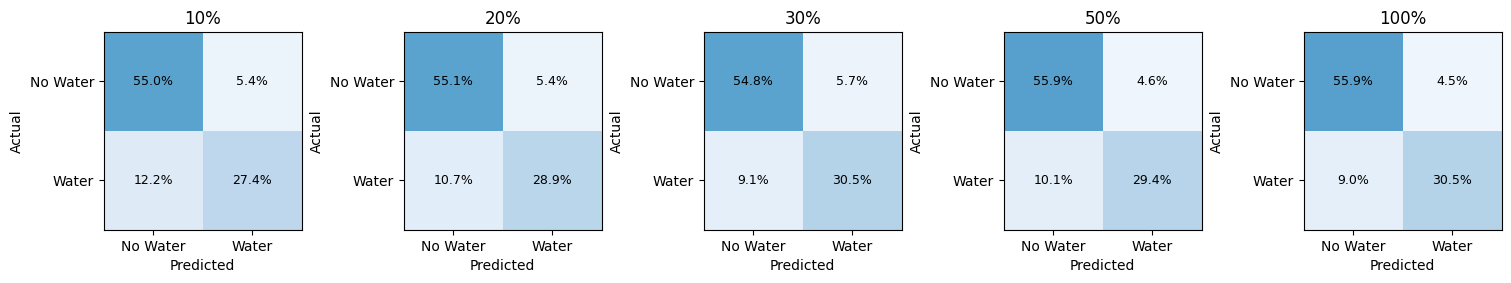

In [29]:
# ================= Confusion matrices per fraction (binary) =================
import numpy as np
import matplotlib.pyplot as plt
import torch

# ---- robust loader that works with your saved checkpoints ----
def load_ckpt_any(path, device="cpu", default_in_ch=768, default_num_classes=2, default_img_size=256):
    import torch, numpy as np, torch.serialization as ts
    try:
        ck = torch.load(path, map_location=device, weights_only=True)
    except Exception:
        try:
            from numpy.core.multiarray import _reconstruct
            ts.add_safe_globals([_reconstruct, np.dtype])
            ck = torch.load(path, map_location=device, weights_only=True)
        except Exception:
            print("[warn] weights_only=False fallback (ensure you trust this file):", path)
            ck = torch.load(path, map_location=device, weights_only=False)

    if isinstance(ck, dict) and "decoder_state" in ck:
        state = ck["decoder_state"]
        meta  = {
            "in_ch":      ck.get("in_ch", default_in_ch),
            "num_classes":ck.get("num_classes", default_num_classes),
            "img_size":   ck.get("img_size", default_img_size),
        }
    elif isinstance(ck, dict):
        state = ck
        meta  = {"in_ch": default_in_ch, "num_classes": default_num_classes, "img_size": default_img_size}
    else:
        raise RuntimeError(f"Unsupported checkpoint type: {type(ck)}")
    return state, meta

@torch.no_grad()
def confusion_on_loader(decoder, loader):
    """Return TN, FP, FN, TP over the whole loader (binary segmentation)."""
    decoder.eval()
    TN = FP = FN = TP = 0
    for b in loader:
        x = b["image"].to(device)
        y = b["mask"].to(device)                 # [B,H,W], values in {0,1}
        f = forward_feats(x)
        pred = decoder(f).argmax(1)              # [B,H,W] in {0,1}

        # move to CPU numpy to count
        p = pred.cpu().numpy().ravel()
        g = y.cpu().numpy().ravel()
        TN += int(np.sum((p==0) & (g==0)))
        FP += int(np.sum((p==1) & (g==0)))
        FN += int(np.sum((p==0) & (g==1)))
        TP += int(np.sum((p==1) & (g==1)))
    return TN, FP, FN, TP

def derive_metrics(TN, FP, FN, TP):
    tot = TN + FP + FN + TP
    oa   = (TP + TN) / max(1, tot)
    prec = TP / max(1, (TP + FP))
    rec  = TP / max(1, (TP + FN))
    f1   = 2*prec*rec / max(1e-9, (prec + rec))
    iou_water = TP / max(1, (TP + FP + FN))
    iou_bg    = TN / max(1, (TN + FN + FP))
    miou = 0.5 * (iou_water + iou_bg)
    return dict(OA=oa, Precision=prec, Recall=rec, F1=f1, IoU_water=iou_water, IoU_bg=iou_bg, mIoU=miou)

def plot_cm(ax, TN, FP, FN, TP, title=""):
    import numpy as np
    cm = np.array([[TN, FP],[FN, TP]], dtype=float)
    cmn = cm / max(1, cm.sum())
    im = ax.imshow(cmn, vmin=0, vmax=1, cmap="Blues")
    for (i,j),v in np.ndenumerate(cmn):
        ax.text(j, i, f"{v*100:.1f}%", ha="center", va="center", fontsize=9)
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(["No Water","Water"])
    ax.set_yticklabels(["No Water","Water"])
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_title(title)
    return im

# ------------------ run for every fraction in your df ------------------
# Ensure we have a list of test pairs if we want to print one example later (optional)
try:
    test_ds = test_dl.dataset
except NameError:
    raise RuntimeError("test_dl (or test_ds) not found. Please run your dataloader build cell first.")

# ------------------ plot a CM per fraction ------------------
n = len(cm_df)
fig, axes = plt.subplots(1, n, figsize=(3*n, 3.8), constrained_layout=True)
if n == 1: axes = [axes]
for ax, r, cm_vals in zip(axes, cm_df.itertuples(index=False), cms):
    TN, FP, FN, TP = cm_vals
    plot_cm(ax, TN, FP, FN, TP, title=f"{int(r.fraction_pct)}%")
plt.show()


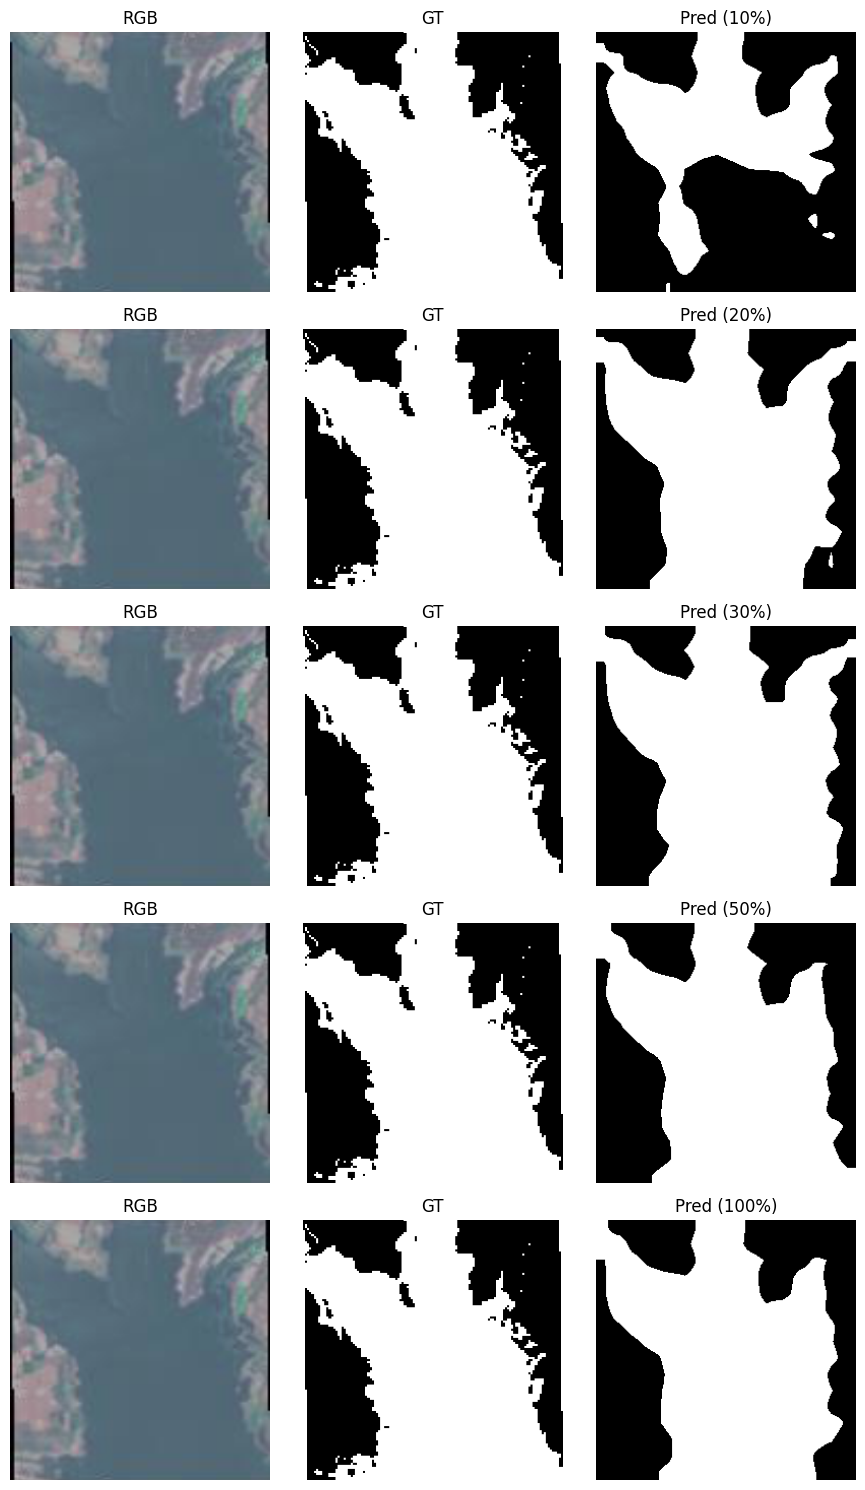

In [67]:
# ===================== Visualize one sample across fractions =====================
import numpy as np
import matplotlib.pyplot as plt
import torch

# --- robust checkpoint loader (same style as before) ---
def load_ckpt_any(path, device="cpu", default_in_ch=768, default_num_classes=2, default_img_size=256):
    import torch, numpy as np, torch.serialization as ts
    try:
        ck = torch.load(path, map_location=device, weights_only=True)
    except Exception:
        try:
            from numpy.core.multiarray import _reconstruct
            ts.add_safe_globals([_reconstruct, np.dtype])
            ck = torch.load(path, map_location=device, weights_only=True)
        except Exception:
            print("[warn] weights_only=False fallback (ensure you trust this file):", path)
            ck = torch.load(path, map_location=device, weights_only=False)

    if isinstance(ck, dict) and "decoder_state" in ck:
        state = ck["decoder_state"]
        meta  = {
            "in_ch":      ck.get("in_ch", default_in_ch),
            "num_classes":ck.get("num_classes", default_num_classes),
            "img_size":   ck.get("img_size", default_img_size),
        }
    elif isinstance(ck, dict):
        state = ck
        meta  = {"in_ch": default_in_ch, "num_classes": default_num_classes, "img_size": default_img_size}
    else:
        raise RuntimeError(f"Unsupported checkpoint type: {type(ck)}")
    return state, meta

@torch.no_grad()
def show_sample_across_fractions(sample_idx=25, fractions=(10,20,30,50,100), thr=0.5):
    # get the underlying test dataset if only the loader exists
    try:
        ds = test_ds
    except NameError:
        ds = test_dl.dataset

    # pull one sample
    sample = ds[sample_idx]
    x0 = sample["image"].unsqueeze(0).to(device)   # [1,3,H,W]
    gt = sample["mask"].cpu().numpy().astype(np.uint8)
    rgb0 = (sample["image"].cpu().numpy().transpose(1,2,0) * std_rgb + mean_rgb).clip(0,1)

    # gather rows for the requested fractions (keep original order)
    rows = []
    for f in fractions:
        match = df[df["fraction_pct"]==f]
        if len(match)==0:
            print(f"[skip] No checkpoint for {f}%")
            continue
        rows.append(match.iloc[0])

    # figure: one row per fraction, 3 columns (RGB, GT, Pred)
    R = len(rows)
    fig, axes = plt.subplots(R, 3, figsize=(9, 3*R))
    if R == 1: axes = np.array([axes])

    for r, row in enumerate(rows):
        # load decoder
        state, meta = load_ckpt_any(row.ckpt, device=device, default_in_ch=768, default_num_classes=2, default_img_size=rgb0.shape[0])
        dec = SmallDecoder(in_ch=meta["in_ch"], num_classes=meta["num_classes"], out_size=(meta["img_size"], meta["img_size"])).to(device)
        dec.load_state_dict(state); dec.eval()

        # forward
        f = forward_feats(x0)                      # encoder features
        logits = dec(f)                            # [1,2,H,W]
        probs = torch.softmax(logits, dim=1)[0,1].detach().cpu().numpy()
        pred  = (probs >= thr).astype(np.uint8)

        # plot
        axes[r,0].imshow((rgb0*255).astype(np.uint8)); axes[r,0].set_title("RGB"); axes[r,0].axis("off")
        axes[r,1].imshow(gt, cmap="gray", vmin=0, vmax=1); axes[r,1].set_title("GT"); axes[r,1].axis("off")
        axes[r,2].imshow(pred, cmap="gray", vmin=0, vmax=1); axes[r,2].set_title(f"Pred ({int(row.fraction_pct)}%)"); axes[r,2].axis("off")

    plt.tight_layout(); plt.show()

# ===== call it =====
show_sample_across_fractions(sample_idx=59, fractions=(10,20,30,50,100), thr=0.5)
